# 03 - From PD to a business decision: expected loss, approval cut-off, pricing

The model produces a probability. A credit decision needs **money**: how much do we expect to lose, how much do we earn, and where do we draw the line?
This notebook: (1) states the expected-loss assumptions, (2) sweeps the approval cut-off, (3) recommends one with a stated rationale, (4) quantifies the
benefit against naive alternatives on the **untouched test vintages**, (5) stress-tests the assumptions, and (6) translates PD into risk-based pricing.

**Discipline:** the cut-off is chosen on the **validation window (2017-18)** only. The test window (2019-21) is used purely to check what would have happened.

> Data note: figures reflect the data loaded (synthetic FOIA-schema stand-in unless real SBA files are in `data/raw/real/`). LGD, margin and
> balance factors are **assumptions**, flagged as such throughout.

In [1]:
import sys
sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import business as biz, config, features, train
from src.evaluation import PALETTE, save_fig, set_style

set_style()
pd.options.display.float_format = "{:,.3f}".format
display(Markdown(f"**Data source loaded: `{train.data_source().upper()}`**"))

model = joblib.load(config.MODEL_PATH)          # the same artefact the API serves
s = train.prepare()
raw_v, pd_v = model.calibrated_pd(s.valid)
raw_t, pd_t = model.calibrated_pd(s.test)
econ = biz.Economics(lgd=model.lgd, ead_factor=model.ead_factor)
print(f"Loaded model trained on '{model.meta['trained_on']}' data, calibrator = {model.meta['calibrator']}, stored cut-off = {model.cutoff:.2%}")

**Data source loaded: `SYNTHETIC`**

Loaded model trained on 'synthetic' data, calibrator = platt, stored cut-off = 9.46%


## 1. Expected-loss framework: EL = PD x LGD x EAD
All quantities are per dollar of `GrossApproval`, so the framework is scale-free.

| Component | Value | Source / justification |
|---|---|---|
| **PD** | model output | Calibrated 36-month probability of charge-off |
| **EAD** | fraction of approval outstanding at default | **Data-derived**: mean of `GrossChargeOffAmount / GrossApproval` over charged-off *training* loans (balance when written off) |
| **LGD** | 45% | **Assumption** - FOIA files do not publish recoveries. 45% is the Basel II foundation-IRB supervisory LGD for senior unsecured corporate exposures; secured / SBA-guaranteed loans would usually be lower. Stress-tested 30-70% in section 5 |
| Net margin | 1.5% p.a. of average balance | **Assumption** - risk-free-adjusted spread net of funding cost, operating cost and cost of capital (before credit losses) |
| Avg balance | 85% of approval | **Assumption** - amortisation over the horizon |
| Horizon | 3 years | Matches the 36-month default window |

Expected loss per $ approved = PD x LGD x EAD-factor. A loan is worth approving when its expected revenue exceeds its expected loss - the
**break-even PD** = revenue rate / (LGD x EAD).

In [2]:
display(pd.Series(econ.to_dict(), name="value").to_frame().style.format("{:.4f}"))
gross_t = s.test["GrossApproval"].to_numpy()
el_pred = (econ.el_rate(pd_t) * gross_t).sum()
el_real = biz.realised_loss(s.test, econ).sum()
print(f"Test portfolio (approve everyone): expected loss ${el_pred/1e6:,.1f}M vs realised loss ${el_real/1e6:,.1f}M on ${gross_t.sum()/1e9:,.2f}B approved "
      f"-> the model under-forecast loss by {1 - el_pred/el_real:.0%}, the calibration drift seen in notebook 02 flowing straight into the dollars.")

,value
lgd,0.4500
ead_factor,0.7033
net_margin,0.0150
avg_balance_factor,0.8500
horizon_years,3.0000
revenue_rate,0.0382
breakeven_pd,0.1209


Test portfolio (approve everyone): expected loss $188.5M vs realised loss $246.4M on $12.37B approved -> the model under-forecast loss by 23%, the calibration drift seen in notebook 02 flowing straight into the dollars.


## 2. Approval cut-off trade-off (validation window)
Rule: approve if calibrated PD <= cut-off. Sweeping the cut-off traces the trade-off between **volume** (approval rate), **risk** (portfolio default rate, EL rate)
and **profit** (expected revenue minus expected loss).

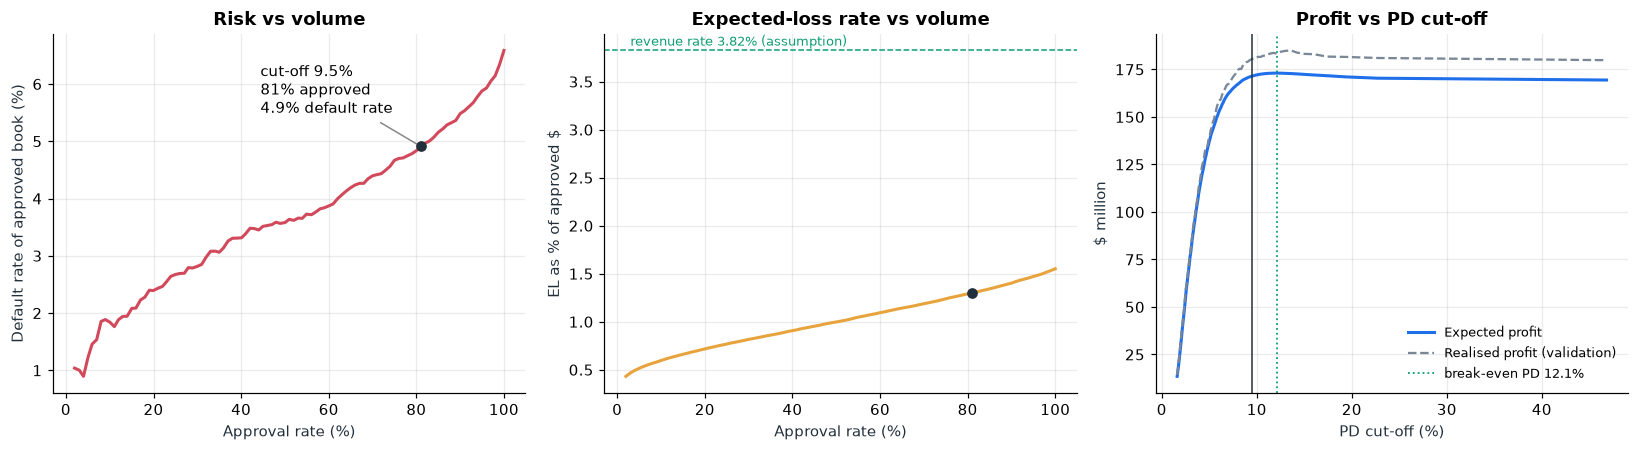

In [3]:
curve_v = biz.cutoff_curve(s.valid, pd_v, econ)
rec = biz.recommend_cutoff(curve_v, tolerance=0.01)
cutoff = float(rec["cutoff"])
best = curve_v.loc[curve_v["expected_profit"].idxmax()]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(curve_v["approval_rate"] * 100, curve_v["default_rate"] * 100, color=PALETTE["bad"], lw=2)
ax[0].scatter([rec["approval_rate"] * 100], [rec["default_rate"] * 100], color=PALETTE["ink"], zorder=5)
ax[0].annotate(f"cut-off {cutoff:.1%}\n{rec['approval_rate']:.0%} approved\n{rec['default_rate']:.1%} default rate", (rec["approval_rate"] * 100, rec["default_rate"] * 100), xytext=(-105, 22), textcoords="offset points", arrowprops=dict(arrowstyle="-", color="#888"))
ax[0].set(title="Risk vs volume", xlabel="Approval rate (%)", ylabel="Default rate of approved book (%)")
ax[1].plot(curve_v["approval_rate"] * 100, curve_v["el_rate_of_approved"] * 100, color=PALETTE["accent"], lw=2)
ax[1].axhline(econ.revenue_rate * 100, color=PALETTE["cal"], ls="--", lw=1); ax[1].text(3, econ.revenue_rate * 100 + .05, f"revenue rate {econ.revenue_rate:.2%} (assumption)", color=PALETTE["cal"], fontsize=8.5)
ax[1].scatter([rec["approval_rate"] * 100], [rec["el_rate_of_approved"] * 100], color=PALETTE["ink"], zorder=5)
ax[1].set(title="Expected-loss rate vs volume", xlabel="Approval rate (%)", ylabel="EL as % of approved $")
ax[2].plot(curve_v["cutoff"] * 100, curve_v["expected_profit"] / 1e6, color=PALETTE["gbm"], lw=2, label="Expected profit")
ax[2].plot(curve_v["cutoff"] * 100, curve_v["realised_profit"] / 1e6, color=PALETTE["lr"], lw=1.5, ls="--", label="Realised profit (validation)")
ax[2].axvline(cutoff * 100, color=PALETTE["ink"], lw=1); ax[2].axvline(econ.breakeven_pd * 100, color=PALETTE["cal"], ls=":", lw=1.2, label=f"break-even PD {econ.breakeven_pd:.1%}")
ax[2].set(title="Profit vs PD cut-off", xlabel="PD cut-off (%)", ylabel="$ million"); ax[2].legend(fontsize=8.5)
fig.tight_layout(); save_fig(fig, "biz_tradeoff_curves"); plt.show()

## 3. Recommended cut-off and rationale
**Rule ("flat-maximum"):** take the *tightest* cut-off whose expected profit is within 1% of the maximum.
Expected profit is nearly flat around its peak (the peak sits near the break-even PD), and the peak location leans on margin/LGD assumptions we cannot
verify from public data. Giving up <=1% of modelled profit for a lower default rate and lower loss buys **robustness to being wrong about the assumptions**.

In [4]:
tbl = curve_v[["cutoff", "approval_rate", "default_rate", "el_rate_of_approved", "expected_profit"]].copy()
pick = pd.concat([curve_v.iloc[(curve_v["cutoff"] - c).abs().argmin():][:1] for c in [0.05, 0.075, cutoff, econ.breakeven_pd, 0.20]])
display(pick[["cutoff", "approval_rate", "default_rate", "el_rate_of_approved", "expected_profit", "realised_profit"]].style.hide(axis="index").format(
    {"cutoff": "{:.1%}", "approval_rate": "{:.1%}", "default_rate": "{:.2%}", "el_rate_of_approved": "{:.2%}", "expected_profit": "${:,.0f}", "realised_profit": "${:,.0f}"}))
display(Markdown(f"**Recommended cut-off: approve if calibrated PD <= {cutoff:.1%}** (profit-maximising cut-off would be {best['cutoff']:.1%}; break-even PD {econ.breakeven_pd:.1%}). "
                 f"On validation this approves **{rec['approval_rate']:.1%}** of applicants, holds the approved-book default rate to **{rec['default_rate']:.2%}** "
                 f"(vs {s.valid['default'].mean():.2%} approving everyone), for {rec['expected_profit'] / best['expected_profit']:.1%} of the maximum expected profit."))

cutoff,approval_rate,default_rate,el_rate_of_approved,expected_profit,realised_profit
5.0%,45.0%,3.51%,0.95%,"$136,757,100","$138,800,659"
7.4%,69.0%,4.35%,1.18%,"$164,641,236","$170,444,142"
9.5%,81.0%,4.91%,1.30%,"$171,381,737","$180,370,168"
12.1%,90.0%,5.48%,1.40%,"$173,040,876","$183,330,112"
19.4%,98.0%,6.14%,1.52%,"$171,064,591","$181,563,458"


**Recommended cut-off: approve if calibrated PD <= 9.5%** (profit-maximising cut-off would be 12.1%; break-even PD 12.1%). On validation this approves **81.0%** of applicants, holds the approved-book default rate to **4.91%** (vs 6.59% approving everyone), for 99.0% of the maximum expected profit.

## 4. Business impact vs naive baselines (out-of-time test, 2019-21)
Compared strategies:
* **Approve everyone** - no model.
* **Rules policy** - a plausible manual policy: decline all start-ups and new (<2y) accommodation/food businesses.
* **Model at the *same approval rate* as the rules policy** - isolates the value of the model's *ranking* (like-for-like volume).
* **Model at the recommended cut-off.**
Realised loss uses each defaulted loan's actual charge-off amount x assumed LGD. Profit = revenue (assumed margin) - realised loss.

strategy,approval_rate,default_rate,loss_rate_realised,loss_rate_vs_approve_all,realised_loss,realised_profit
Approve everyone,100.0%,8.37%,1.99%,+0.0%,"$246,382,171","$226,928,872"
Rules policy (decline start-ups & new NAICS-72),84.9%,7.27%,1.59%,-20.2%,"$167,663,735","$235,877,338"
"Model, same approval rate as rules",84.9%,6.53%,1.72%,-13.4%,"$199,095,728","$242,432,736"
Model @ recommended cut-off (9.5%),81.8%,6.28%,1.68%,-15.5%,"$190,856,870","$242,844,531"


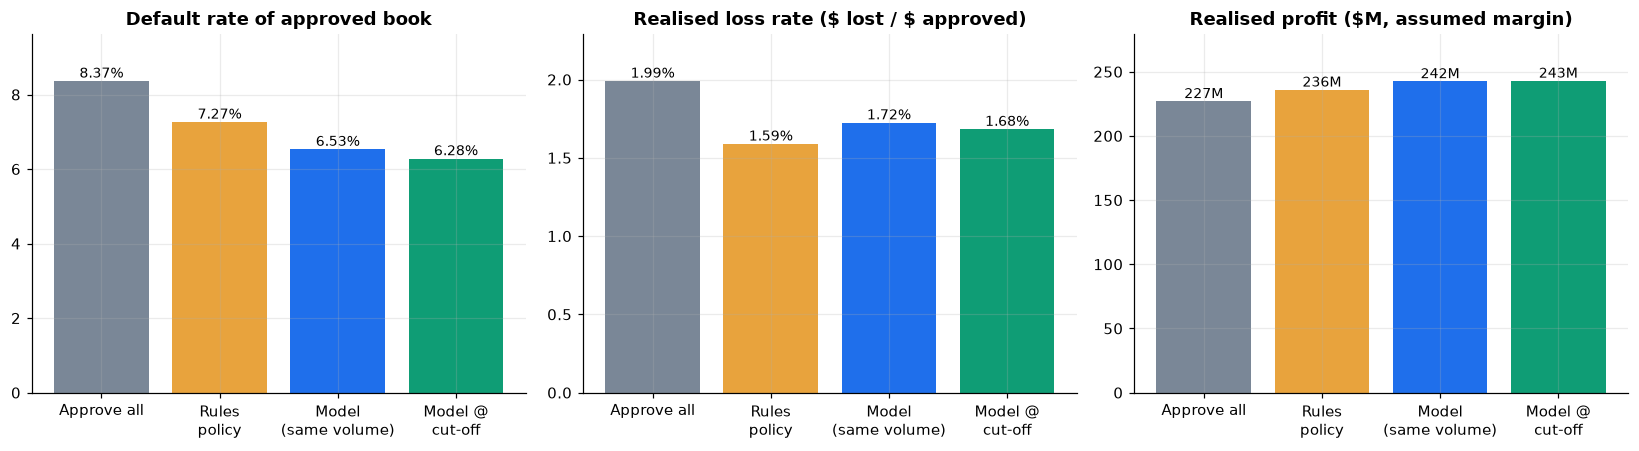

**Impact on the test vintages.** At the recommended cut-off the model approves 82% of loans and cuts the realised loss rate by **15%** vs approving everyone (1.99% -> 1.68% of approved dollars), avoiding $56M of realised loss, while realised profit changes by $+16M.  
**Model vs rules policy at like-for-like volume (85% approved):** the model's approved book has a **10% lower default rate** (6.53% vs 7.27%) and **$+7M** realised profit, but a 9% HIGHER *dollar* loss rate (1.72% vs 1.59%). The model ranks on PD (a count-based risk); the loss-rate metric is dollar-weighted, and this simple rules policy happens to remove segments that matter for dollars. So the honest summary is: **the model is clearly better at picking who defaults, and on profit, but it does not beat a sensible manual rule on dollar loss rate at equal volume** - a size-aware decision (tighter PD cut-off for larger loans, or ranking on PD x EAD) is the natural next step (see limitations).

In [5]:
rules_decline = biz.rules_baseline_decline(s.X("test"))
cmp = biz.compare_strategies(s.test, pd_t, rules_decline, econ, cutoff)
disp = cmp[["strategy", "approval_rate", "default_rate", "loss_rate_realised", "loss_rate_vs_approve_all", "realised_loss", "realised_profit"]].copy()
display(disp.style.hide(axis="index").format({"approval_rate": "{:.1%}", "default_rate": "{:.2%}", "loss_rate_realised": "{:.2%}", "loss_rate_vs_approve_all": "{:+.1%}",
                                              "realised_loss": "${:,.0f}", "realised_profit": "${:,.0f}"}))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
short = ["Approve all", "Rules\npolicy", "Model\n(same volume)", "Model @\ncut-off"]
colors = [PALETTE["lr"], PALETTE["accent"], PALETTE["gbm"], PALETTE["cal"]]
for a, col, title, fmt in zip(ax, ["default_rate", "loss_rate_realised", "realised_profit"], ["Default rate of approved book", "Realised loss rate (\\$ lost / \\$ approved)", "Realised profit ($M, assumed margin)"], ["{:.1%}", "{:.2%}", "${:,.0f}M"]):
    vals = cmp[col] * (1e-6 if col == "realised_profit" else 100 if col != "realised_profit" else 1)
    a.bar(short, vals, color=colors)
    for i, v in enumerate(vals):
        a.text(i, v, (f"{v:,.0f}M" if col == "realised_profit" else f"{v:.2f}%"), ha="center", va="bottom", fontsize=9)
    a.set(title=title); a.set_ylim(0, vals.max() * 1.15)
fig.tight_layout(); save_fig(fig, "biz_strategy_comparison"); plt.show()

r_all, r_rules, r_match, r_cut = (cmp.iloc[i] for i in range(4))
dr_gain = 1 - r_match["default_rate"] / r_rules["default_rate"]
lr_gain = 1 - r_match["loss_rate_realised"] / r_rules["loss_rate_realised"]
profit_gain = (r_match["realised_profit"] - r_rules["realised_profit"]) / 1e6
lr_word = f"{abs(lr_gain):.0%} {'lower' if lr_gain > 0 else 'HIGHER'}"
display(Markdown(
    f"**Impact on the test vintages.** At the recommended cut-off the model approves {r_cut['approval_rate']:.0%} of loans and cuts the realised loss rate by "
    f"**{-r_cut['loss_rate_vs_approve_all']:.0%}** vs approving everyone ({r_all['loss_rate_realised']:.2%} -> {r_cut['loss_rate_realised']:.2%} of approved dollars), avoiding "
    f"${(r_all['realised_loss'] - r_cut['realised_loss'])/1e6:,.0f}M of realised loss, while realised profit changes by ${(r_cut['realised_profit'] - r_all['realised_profit'])/1e6:+,.0f}M.  \n"
    f"**Model vs rules policy at like-for-like volume ({r_rules['approval_rate']:.0%} approved):** the model's approved book has a **{dr_gain:.0%} lower default rate** "
    f"({r_match['default_rate']:.2%} vs {r_rules['default_rate']:.2%}) and **${profit_gain:+,.0f}M** realised profit, but a {lr_word} *dollar* loss rate "
    f"({r_match['loss_rate_realised']:.2%} vs {r_rules['loss_rate_realised']:.2%}). The model ranks on PD (a count-based risk); the loss-rate metric is dollar-weighted, and this simple rules "
    f"policy happens to remove segments that matter for dollars. So the honest summary is: **the model is clearly better at picking who defaults, and on profit, "
    f"but it does not beat a sensible manual rule on dollar loss rate at equal volume** - a size-aware decision (tighter PD cut-off for larger loans, or ranking on PD x EAD) is the natural next step (see limitations)."))

## 5. Stress-testing the assumptions
Because LGD and margin are assumptions, we show how the recommended cut-off moves (and what the model would still deliver) when they change, and how a
**PD stress** (calibration drift like the 2020 vintage) changes the picture.

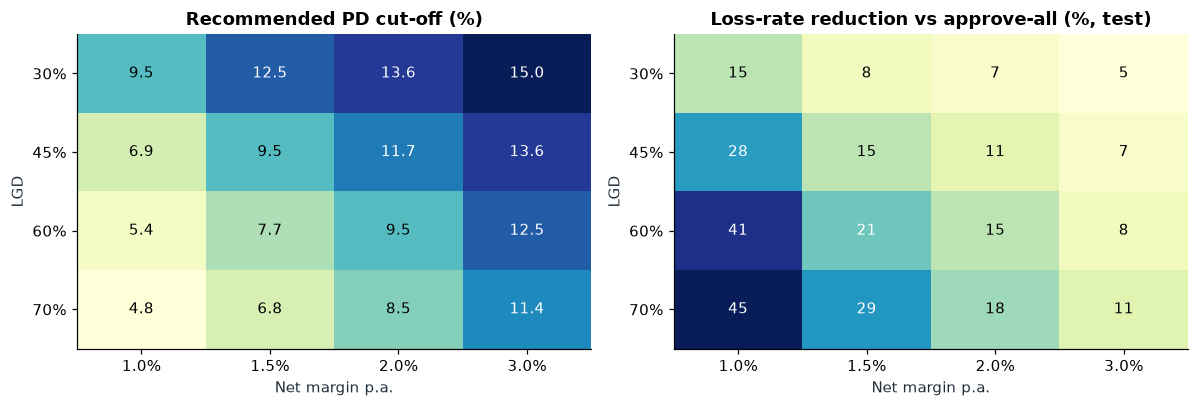

Reading: higher assumed LGD or thinner margin -> tighter cut-off (approve fewer), and the loss reduction vs approve-all stays positive across the grid.


PD multiplier,recommended cut-off,approval rate (test),default rate of approved (test)
1.000000,9.5%,81.8%,6.28%
1.150000,9.8%,77.0%,6.01%
1.300000,10.2%,73.1%,5.71%


In [6]:
lgds, margins = [0.30, 0.45, 0.60, 0.70], [0.010, 0.015, 0.020, 0.030]
grid_cut = np.zeros((len(lgds), len(margins))); grid_app = np.zeros_like(grid_cut); grid_red = np.zeros_like(grid_cut)
for i, l in enumerate(lgds):
    for j, mg in enumerate(margins):
        e = biz.Economics(lgd=l, ead_factor=econ.ead_factor, net_margin=mg)
        c = biz.recommend_cutoff(biz.cutoff_curve(s.valid, pd_v, e))["cutoff"]
        grid_cut[i, j] = c
        cm = biz.compare_strategies(s.test, pd_t, rules_decline, e, c)
        grid_app[i, j] = cm.loc[3, "approval_rate"]; grid_red[i, j] = -cm.loc[3, "loss_rate_vs_approve_all"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, g, title, f in ((ax[0], grid_cut * 100, "Recommended PD cut-off (%)", "{:.1f}"), (ax[1], grid_red * 100, "Loss-rate reduction vs approve-all (%, test)", "{:.0f}")):
    im = a.imshow(g, cmap="YlGnBu", aspect="auto")
    a.set_xticks(range(len(margins))); a.set_xticklabels([f"{m:.1%}" for m in margins]); a.set_yticks(range(len(lgds))); a.set_yticklabels([f"{l:.0%}" for l in lgds])
    for i in range(len(lgds)):
        for j in range(len(margins)):
            a.text(j, i, f.format(g[i, j]), ha="center", va="center", color="white" if g[i, j] > g.mean() else "black")
    a.set(title=title, xlabel="Net margin p.a.", ylabel="LGD"); a.grid(False)
fig.tight_layout(); save_fig(fig, "biz_sensitivity"); plt.show()
print("Reading: higher assumed LGD or thinner margin -> tighter cut-off (approve fewer), and the loss reduction vs approve-all stays positive across the grid.")

# PD stress: multiply calibrated PDs by k (a 2020-style level shift) and see EL and the cut-off
rows = []
for k in (1.0, 1.15, 1.3):
    pv, pt = np.clip(pd_v * k, 0, 1), np.clip(pd_t * k, 0, 1)
    c = biz.recommend_cutoff(biz.cutoff_curve(s.valid, pv, econ))["cutoff"]
    rows.append({"PD multiplier": k, "recommended cut-off": c, "approval rate (test)": (pt <= c).mean(), "default rate of approved (test)": s.test["default"].to_numpy()[pt <= c].mean()})
display(pd.DataFrame(rows).style.hide(axis="index").format({"recommended cut-off": "{:.1%}", "approval rate (test)": "{:.1%}", "default rate of approved (test)": "{:.2%}"}))

## 6. Risk-based pricing
Approve/decline is blunt. A lender can also price the risk: the **annualised expected-loss charge** for each PD quintile is what the rate must add on top of the
base margin to earn the same return. Comparing it with the spread over prime actually charged shows where pricing is not risk-sensitive enough.

band,loans,mean_pd,annual_el_pct,required_spread_pct,actual_spread_over_prime_pct
Q1,"5,958",2.34%,0.29,1.79,2.14
Q2,"5,958",3.83%,0.48,1.98,2.29
Q3,"5,958",5.35%,0.66,2.16,2.47
Q4,"5,958",7.51%,0.93,2.43,2.66
Q5,"5,958",13.45%,1.67,3.17,3.12


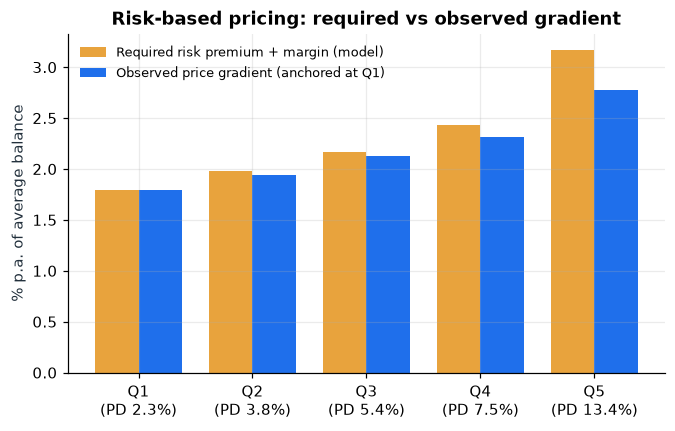

Moving from the safest to the riskiest PD quintile, the model says the price should rise by **1.4 pp** (EL charge 0.29% -> 1.67% p.a.), whereas observed spreads over prime rise by only **1.0 pp**: the riskiest borrowers are under-priced relative to their expected loss. (Caveat: SBA caps maximum 7(a) rates by loan size/term, so lenders cannot always price the full risk - which is exactly why a cut-off is the more important lever.)

In [7]:
Xv = s.X("test")
pt_tbl = biz.pricing_table(s.test, pd_t, econ, n_bands=5, actual_spread=Xv["rate_spread"].to_numpy())
display(pt_tbl.style.hide(axis="index").format({"loans": "{:,.0f}", "mean_pd": "{:.2%}", "annual_el_pct": "{:.2f}", "required_spread_pct": "{:.2f}", "actual_spread_over_prime_pct": "{:.2f}"}))
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(pt_tbl)); w = .38
ax.bar(x - w/2, pt_tbl["annual_el_pct"] + econ.net_margin * 100, w, color=PALETTE["accent"], label="Required risk premium + margin (model)")
ax.bar(x + w/2, pt_tbl["actual_spread_over_prime_pct"] - pt_tbl["actual_spread_over_prime_pct"].iloc[0] + econ.net_margin * 100 + pt_tbl["annual_el_pct"].iloc[0], w, color=PALETTE["gbm"], label="Observed price gradient (anchored at Q1)")
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n(PD {p:.1%})" for b, p in zip(pt_tbl["band"], pt_tbl["mean_pd"])])
ax.set(title="Risk-based pricing: required vs observed gradient", ylabel="% p.a. of average balance"); ax.legend(fontsize=8.5)
save_fig(fig, "biz_pricing"); plt.show()
q1, q5 = pt_tbl.iloc[0], pt_tbl.iloc[-1]
display(Markdown(f"Moving from the safest to the riskiest PD quintile, the model says the price should rise by **{q5['required_spread_pct'] - q1['required_spread_pct']:.1f} pp** "
                 f"(EL charge {q1['annual_el_pct']:.2f}% -> {q5['annual_el_pct']:.2f}% p.a.), whereas observed spreads over prime rise by only "
                 f"**{q5['actual_spread_over_prime_pct'] - q1['actual_spread_over_prime_pct']:.1f} pp**: the riskiest borrowers are under-priced relative to their expected loss. "
                 f"(Caveat: SBA caps maximum 7(a) rates by loan size/term, so lenders cannot always price the full risk - which is exactly why a cut-off is the more important lever.)"))

## 7. Recommendation (as I would say it in the room)

In [8]:
display(Markdown(f"""
1. **Approve when the calibrated 36-month PD is at or below {cutoff:.1%}; decline (or refer to manual review / require more collateral) above it.**
2. Why this number: it sits at the tightest end of the profit plateau - within 1% of maximum expected profit, right by the modelled break-even PD ({econ.breakeven_pd:.1%}) -
   so it is robust to being wrong about margin and LGD (section 5).
3. Impact (test vintages 2019-21, decided on 2017-18): approves {r_cut['approval_rate']:.0%} of loans, cuts the realised loss rate by **{-r_cut['loss_rate_vs_approve_all']:.0%}** vs approving everyone,
   and, at equal volume to the manual rules policy, has a **{dr_gain:.0%} lower default rate** and ${profit_gain:+,.0f}M higher realised profit (but not a lower dollar loss rate - see section 4).
4. **Price the risk** in the declined-but-close band and the top quintile rather than only accepting/declining: those borrowers are under-priced today.
5. **Monitor and re-calibrate:** levels drifted by several points in 2020 while ranking held. Track predicted-vs-observed by vintage each quarter and refresh the calibration intercept
   (or apply a macro overlay) as soon as new vintages mature.

**What this does not tell you:** SBA data only contains *approved* loans (no reject inference), LGD/margin are assumptions, and the loss view is at full exposure - the
SBA guarantee (50-85% for 7(a)) shifts a large share of loss to SBA, which a lender-specific analysis would model explicitly.
"""))


1. **Approve when the calibrated 36-month PD is at or below 9.5%; decline (or refer to manual review / require more collateral) above it.**
2. Why this number: it sits at the tightest end of the profit plateau - within 1% of maximum expected profit, right by the modelled break-even PD (12.1%) -
   so it is robust to being wrong about margin and LGD (section 5).
3. Impact (test vintages 2019-21, decided on 2017-18): approves 82% of loans, cuts the realised loss rate by **15%** vs approving everyone,
   and, at equal volume to the manual rules policy, has a **10% lower default rate** and $+7M higher realised profit (but not a lower dollar loss rate - see section 4).
4. **Price the risk** in the declined-but-close band and the top quintile rather than only accepting/declining: those borrowers are under-priced today.
5. **Monitor and re-calibrate:** levels drifted by several points in 2020 while ranking held. Track predicted-vs-observed by vintage each quarter and refresh the calibration intercept
   (or apply a macro overlay) as soon as new vintages mature.

**What this does not tell you:** SBA data only contains *approved* loans (no reject inference), LGD/margin are assumptions, and the loss view is at full exposure - the
SBA guarantee (50-85% for 7(a)) shifts a large share of loss to SBA, which a lender-specific analysis would model explicitly.
